**PRCP-1010-Insurance Claim Prediction**

**Domain Analysis:**
This project is based on the insurance industry, where the goal is to predict whether a policy holder will file a claim in the furture.The insurance compabiies use preedictive models to estimate the risk level of customers.
The primary goal of this project is to predict whether a customer will claim the insurance or not.
*   Target = 1 -->claim
*   Target = 0 -->
No Claim



This dataset consists of anonymous features such as:


* ps_ind_ -individual related features
*  ps_car_* - Vehicle related feature
* ps_calc_*- calcualted feature
* *_bin - binary features
*  *_cat - categorical features





In [ ]:
# Import all the libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

In [ ]:
# Load the data
data = pd.read_csv("/content/train.csv")

**Basic Checks**

In [ ]:
# Check the shape of the data
data.shape

(237556, 59)

In [ ]:
# First 5 rows of the data
data.head()

,id,target,ps_ind_01,ps_ind_02_cat,ps_ind_03,ps_ind_04_cat,ps_ind_05_cat,ps_ind_06_bin,ps_ind_07_bin,ps_ind_08_bin,...,ps_calc_11,ps_calc_12,ps_calc_13,ps_calc_14,ps_calc_15_bin,ps_calc_16_bin,ps_calc_17_bin,ps_calc_18_bin,ps_calc_19_bin,ps_calc_20_bin
0,7,0,2,2,5,1,0,0,1,0,...,9,1,5,8,0,1.0,1.0,0.0,0.0,1.0
1,9,0,1,1,7,0,0,0,0,1,...,3,1,1,9,0,1.0,1.0,0.0,1.0,0.0
2,13,0,5,4,9,1,0,0,0,1,...,4,2,7,7,0,1.0,1.0,0.0,1.0,0.0
3,16,0,0,1,2,0,0,1,0,0,...,2,2,4,9,0,0.0,0.0,0.0,0.0,0.0
4,17,0,0,2,0,1,0,1,0,0,...,3,1,1,3,0,0.0,0.0,1.0,1.0,0.0


In [ ]:
# Last 5 rows of the data
data.tail()

,id,target,ps_ind_01,ps_ind_02_cat,ps_ind_03,ps_ind_04_cat,ps_ind_05_cat,ps_ind_06_bin,ps_ind_07_bin,ps_ind_08_bin,...,ps_calc_11,ps_calc_12,ps_calc_13,ps_calc_14,ps_calc_15_bin,ps_calc_16_bin,ps_calc_17_bin,ps_calc_18_bin,ps_calc_19_bin,ps_calc_20_bin
237551,593372,0,0,2,1,1,0,1,0,0,...,5,1,1,7,0,1.0,1.0,0.0,0.0,0.0
237552,593373,0,0,2,1,0,0,1,0,0,...,5,0,4,8,0,0.0,0.0,1.0,1.0,0.0
237553,593379,0,3,1,3,0,0,0,0,0,...,5,0,4,5,0,1.0,1.0,0.0,0.0,0.0
237554,593386,0,1,4,6,1,2,0,1,0,...,6,3,3,6,1,0.0,1.0,0.0,0.0,0.0
237555,593389,0,0,1,5,0,0,0,0,1,...,5,1,0,13,0,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Check all the column names are in readable format if not change column names
data.columns

Index(['id', 'target', 'ps_ind_01', 'ps_ind_02_cat', 'ps_ind_03',
       'ps_ind_04_cat', 'ps_ind_05_cat', 'ps_ind_06_bin', 'ps_ind_07_bin',
       'ps_ind_08_bin', 'ps_ind_09_bin', 'ps_ind_10_bin', 'ps_ind_11_bin',
       'ps_ind_12_bin', 'ps_ind_13_bin', 'ps_ind_14', 'ps_ind_15',
       'ps_ind_16_bin', 'ps_ind_17_bin', 'ps_ind_18_bin', 'ps_reg_01',
       'ps_reg_02', 'ps_reg_03', 'ps_car_01_cat', 'ps_car_02_cat',
       'ps_car_03_cat', 'ps_car_04_cat', 'ps_car_05_cat', 'ps_car_06_cat',
       'ps_car_07_cat', 'ps_car_08_cat', 'ps_car_09_cat', 'ps_car_10_cat',
       'ps_car_11_cat', 'ps_car_11', 'ps_car_12', 'ps_car_13', 'ps_car_14',
       'ps_car_15', 'ps_calc_01', 'ps_calc_02', 'ps_calc_03', 'ps_calc_04',
       'ps_calc_05', 'ps_calc_06', 'ps_calc_07', 'ps_calc_08', 'ps_calc_09',
       'ps_calc_10', 'ps_calc_11', 'ps_calc_12', 'ps_calc_13', 'ps_calc_14',
       'ps_calc_15_bin', 'ps_calc_16_bin', 'ps_calc_17_bin', 'ps_calc_18_bin',
       'ps_calc_19_bin', 'ps_calc_20_bin'],


In [ ]:
# Check for duplicates
data.duplicated().sum()

np.int64(0)

In [ ]:
# Check for null values
data.isnull().sum()

,0
id,0
target,0
ps_ind_01,0
ps_ind_02_cat,0
ps_ind_03,0
ps_ind_04_cat,0
ps_ind_05_cat,0
ps_ind_06_bin,0
ps_ind_07_bin,0
ps_ind_08_bin,0


In [ ]:
# Check the information of the data
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 237556 entries, 0 to 237555
Data columns (total 59 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   id              237556 non-null  int64  
 1   target          237556 non-null  int64  
 2   ps_ind_01       237556 non-null  int64  
 3   ps_ind_02_cat   237556 non-null  int64  
 4   ps_ind_03       237556 non-null  int64  
 5   ps_ind_04_cat   237556 non-null  int64  
 6   ps_ind_05_cat   237556 non-null  int64  
 7   ps_ind_06_bin   237556 non-null  int64  
 8   ps_ind_07_bin   237556 non-null  int64  
 9   ps_ind_08_bin   237556 non-null  int64  
 10  ps_ind_09_bin   237556 non-null  int64  
 11  ps_ind_10_bin   237556 non-null  int64  
 12  ps_ind_11_bin   237556 non-null  int64  
 13  ps_ind_12_bin   237556 non-null  int64  
 14  ps_ind_13_bin   237556 non-null  int64  
 15  ps_ind_14       237556 non-null  int64  
 16  ps_ind_15       237556 non-null  int64  
 17  ps_ind_16_

In [ ]:
# Check the statistical summary of the data
data.describe().T

,count,mean,std,min,25%,50%,75%,max
id,237556.0,296980.335925,171249.809414,7.000000,148806.500000,297021.500000,445267.250000,593389.000000
target,237556.0,0.036404,0.187294,0.000000,0.000000,0.000000,0.000000,1.000000
ps_ind_01,237556.0,1.897064,1.984856,0.000000,0.000000,1.000000,3.000000,7.000000
ps_ind_02_cat,237556.0,1.358345,0.663217,-1.000000,1.000000,1.000000,2.000000,4.000000
ps_ind_03,237556.0,4.424565,2.702860,0.000000,2.000000,4.000000,6.000000,11.000000
ps_ind_04_cat,237556.0,0.416714,0.493263,-1.000000,0.000000,0.000000,1.000000,1.000000
ps_ind_05_cat,237556.0,0.405029,1.349701,-1.000000,0.000000,0.000000,0.000000,6.000000
ps_ind_06_bin,237556.0,0.393444,0.488515,0.000000,0.000000,0.000000,1.000000,1.000000
ps_ind_07_bin,237556.0,0.256184,0.436525,0.000000,0.000000,0.000000,1.000000,1.000000
ps_ind_08_bin,237556.0,0.163713,0.370016,0.000000,0.000000,0.000000,0.000000,1.000000


In [ ]:
# Check the target column is balanced or not
data['target'].value_counts(normalize=True) * 100

,proportion
target,
0,96.359595
1,3.640405


In [ ]:
# Drop the necessary columns
data.drop('id',axis=1,inplace=True)

**Correlation Heatmap***

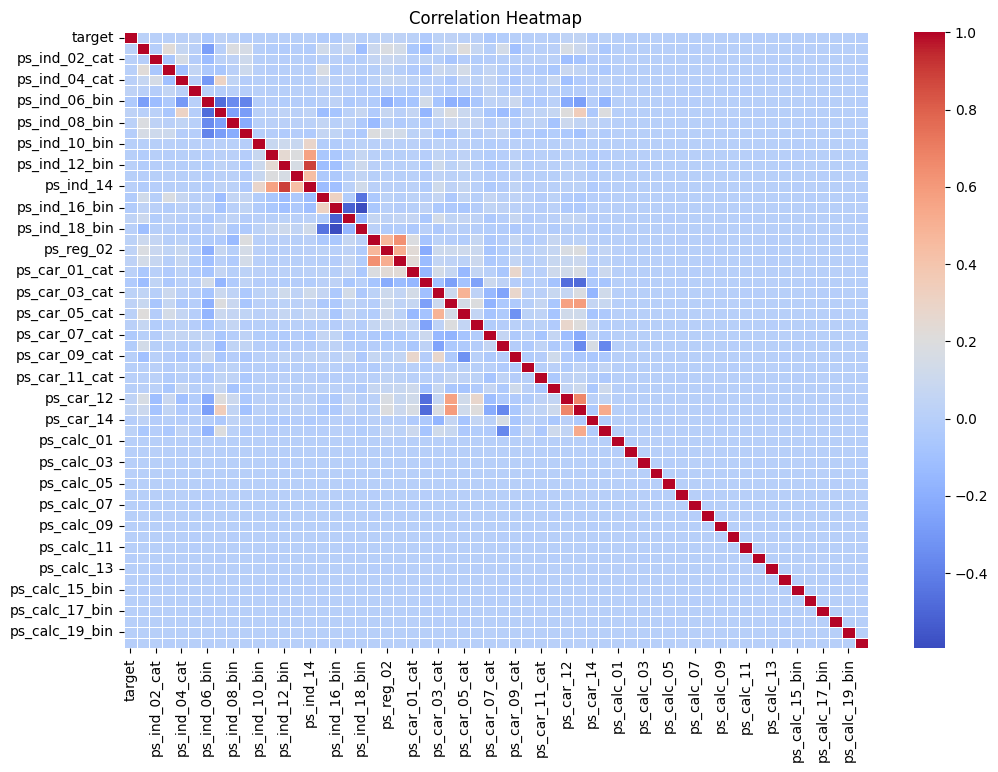

In [ ]:
plt.figure(figsize=(12,8))
correlation_matrix = data.corr()
sns.heatmap(correlation_matrix,annot=False,cmap='coolwarm',linewidth=0.5)
plt.title('Correlation Heatmap')
plt.show()

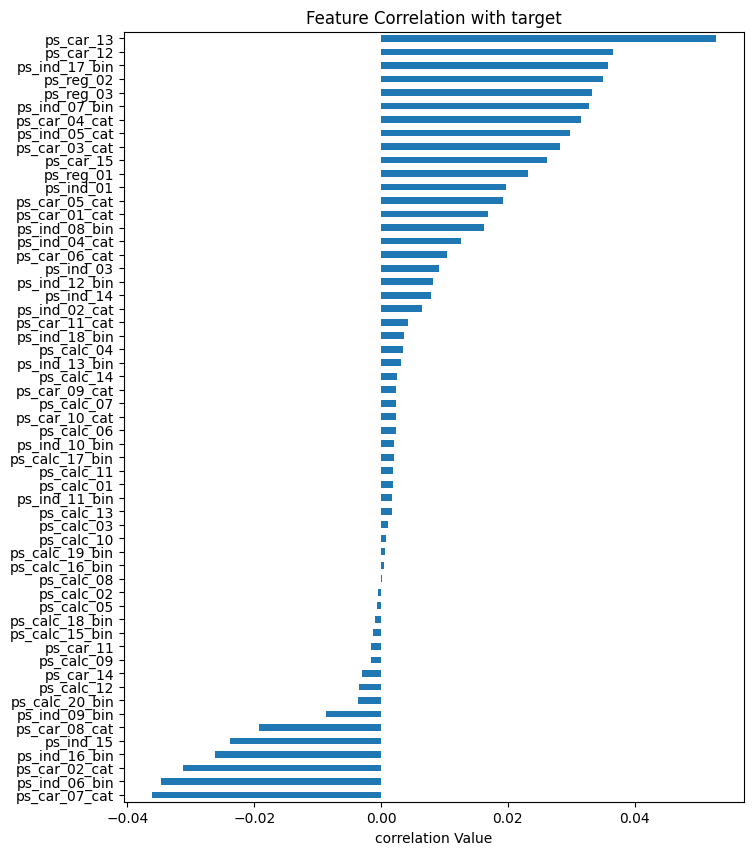

In [ ]:
# Heatmap with the target column
target_corr = data.corr()['target'].drop('target').sort_values()
plt.figure(figsize=(8,10))
target_corr.plot(kind='barh')
plt.title("Feature Correlation with target")
plt.xlabel("correlation Value")
plt.show()

**Feature-Target Split**

In [ ]:
# Divide the data into X and y
X = data.drop("target",axis=1)
y = data['target']

In [ ]:
# Split the data for train and test
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,stratify = y,random_state=42
)

**Winsorization**

In [ ]:
def cap_outliers_iqr(data,column):
  Q1 = data[column].quantile(0.25)
  Q3 = data[column].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR

  data[column] = np.where(data[column] < lower_bound,lower_bound,data[column])
  data[column] = np.where(data[column] > upper_bound,upper_bound, data[column])
  return data
  X_train_capped = X_train.copy()
  X_test_capped = X_test.copy()

  num_cols = X_train.select_dtypes(include=['int64','float64']).columns
  for col in num_cols:
    if col != 'target':
      X_train_capped = cap_outliers_iqr(X_train_capped,col)
      Q1_test = X_train[col].quantile(0.25)
      Q3_test = X_train[col].quantile(0.75)
      IQR_test = Q3_test - Q1_test
      lower_bound_test = Q1_test - 1.5 * IQR_test
      upper_bound_test = Q3_test  + 1.5 * IQR_test

      X_test_capped[col] = np.where(X_test_capped[col] < lower_bound_test,lower_bound_test,X_test_capped[col])
      X_test_cappped[col] = np.where(X_test_capped[col] > upper_bound_test,upper_bound_test,X_test_capped)
      print("Outlier capping is applied successfully!!")
      return X_train_capped,X_test_capped

**Feature Engineering**

In [ ]:
# Seperate num and cat columns Handle null values using the pipeline Preprocessing
from sklearn.preprocessing import OneHotEncoder
num_cols = X.select_dtypes(include=['int64','float64']).columns
cat_cols = X.select_dtypes(include=['object','category']).columns

num_transformer = Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='median')),
    ('scaler',StandardScaler())
    ])

cat_transformer = Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('onehot',OneHotEncoder(handle_unknown='ignore'))
  ])
preprocessor = ColumnTransformer(transformers=[
    ('num',num_transformer,num_cols),
    ('cat',cat_transformer,cat_cols)
])

In [ ]:
# To identify class imbalance check the neg and pos
# This helps to decide whether to use SMOTE,class_weighting and threshold tuning techniques
neg,pos = np.bincount(y_train)
print('Negative:',neg)
print('Positive:',pos)
print('Ratio:',neg/pos)

Negative: 183126
Positive: 6918
Ratio: 26.470945359930617


In [ ]:
# Applied SMOTE for LogisticRegression
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.metrics import classification_report,roc_auc_score
log_pipeline = ImbPipeline([
    ('preprocessor',preprocessor),
    ('smote',SMOTE(random_state=42)),
    ('model',LogisticRegression(
                class_weight='balanced',
                max_iter=1000,
                random_state=42))
])

log_pipeline.fit(X_train,y_train)
y_pred = log_pipeline.predict(X_test)
y_prob = log_pipeline.predict_proba(X_test)[:,1]

print("Classification Report:",classification_report(y_test,y_pred))
print("ROC-AUC:",roc_auc_score(y_test,y_pred))

Classification Report:               precision    recall  f1-score   support

           0       0.97      0.59      0.74     45782
           1       0.05      0.55      0.09      1730

    accuracy                           0.59     47512
   macro avg       0.51      0.57      0.41     47512
weighted avg       0.94      0.59      0.71     47512

ROC-AUC: 0.5694270004896288


In [ ]:
# Find the Automatic threshold values instead using of default 0.5
from sklearn.metrics import f1_score
thresholds = np.arange(0.1,0.9,0.01)
best_f1 = 0
best_threshold = 0
for t in thresholds:
  preds = (y_prob >= t).astype(int)
  f1 = f1_score(y_test,preds)

  if f1 > best_f1:
    best_f1 = f1
    best_threshold =t

print("Best Threshold:",best_threshold)
print("Best F1 Score:",best_f1)

Best Threshold: 0.5999999999999998
Best F1 Score: 0.10013780431786863


**Model Building**

In [ ]:
# Model Initialization
models ={
    "LogisticRegression":LogisticRegression(max_iter=1000,class_weight='balanced'),
    "Random Forest": RandomForestClassifier(n_estimators=200,class_weight='balanced',random_state=42),
    "Decision Tree" : DecisionTreeClassifier(class_weight='balanced',random_state=42),
    "Naive Bayes" : GaussianNB(),
    "KNN" : KNeighborsClassifier(),
    "XGBoost": XGBClassifier(n_estimators=400,max_depth=6,learning_rate=0.05,random_state=42)
}

In [ ]:
# Train the models
trained_models = {}
for name, model in models.items():
  pipeline = Pipeline([
      ('preprocessor',preprocessor),
      ('classifier',model)
  ])

  pipeline.fit(X_train,y_train)
  trained_models[name] = pipeline
  print(f"{name} trained")

LogisticRegression trained
Random Forest trained
Decision Tree trained
Naive Bayes trained
KNN trained
XGBoost trained


In [ ]:
# Create a function and add the training results to that function
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report
def evaluate_model(model, X_test, y_test, threshold=0.5):

  y_prob = model.predict_proba(X_test)[:,1]
  y_pred = (y_prob >= threshold).astype(int)
  return{
      "Accuracy":accuracy_score(y_test,y_pred),
      "Precision":precision_score(y_test,y_pred),
      "Recall" : recall_score(y_test,y_pred),
      "F1 Score" : f1_score(y_test,y_pred),
      "ROC-AUC": roc_auc_score(y_test,y_prob)
  }

In [ ]:
results=[]
for name, model in trained_models.items():
  metrics = evaluate_model(model,X_test,y_test)
  metrics["Model"] = name
  results.append(metrics)
  results_df = pd.DataFrame(results)
  results_df = results_df[[
      "Model",
      "Accuracy",
      "Precision",
      "Recall",
      "F1 Score",
      "ROC-AUC"
  ]]

**Model Comparison Table**

In [ ]:
# Result
results_df = results_df.sort_values(by="ROC-AUC",ascending=False)
results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,LogisticRegression,0.622283,0.050109,0.516942,0.091363,0.604023
3,Naive Bayes,0.906201,0.064327,0.114683,0.082423,0.600531
5,XGBoost,0.963234,0.000000,0.000000,0.000000,0.590758
1,Random Forest,0.963266,0.000000,0.000000,0.000000,0.575113
4,KNN,0.962851,0.066667,0.000869,0.001715,0.511445
2,Decision Tree,0.926850,0.040290,0.043440,0.041806,0.501990


**Insights:**
Due to severe class imbalance the approximate ratio of this data is (~96:4),multiple models were tested. Logistic Regression provide the most balanced performance with optimized threshold tuning. SMOTE was experimented but it yielded marginal improvement, indicating limited separability

**ROC Curve**

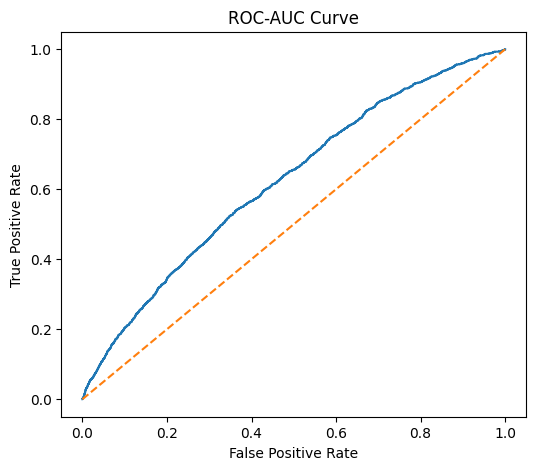

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
fpr,tpr,thresholds = roc_curve(y_test,y_prob)
roc_auc = roc_auc_score(y_test,y_prob)
plt.figure(figsize=(6,5))
plt.plot(fpr,tpr,label=f'ROC Curve (AUC = {roc_auc:.3f})')
plt.plot([0,1],[0,1],linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-AUC Curve')
plt.show()

**Logistic Regression with SMOTE**

In [ ]:
from sklearn.linear_model import LogisticRegression
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
log_smote_pipeline = ImbPipeline([
    ('preprocessor',preprocessor),
    ('smote',SMOTE(random_state=42)),
    ('classifier',LogisticRegression(max_iter=1000))
])

log_smote_pipeline.fit(X_train,y_train)

trained_models["Logistic SMOTE"] = log_smote_pipeline
print("Logistic Regression with SMOTE is trained...")

Logistic Regression with SMOTE is trained...


In [ ]:
metrics = evaluate_model(trained_models["Logistic SMOTE"],X_test,y_test)
print(metrics)

{'Accuracy': 0.5898509850143122, 'Precision': 0.048190931759198, 'Recall': 0.5473988439306359, 'F1 Score': 0.08858332164070903, 'ROC-AUC': np.float64(0.6015834781723791)}


In [ ]:
# BalancedRandomForestClassifier
from imblearn.ensemble import BalancedRandomForestClassifier
brf = BalancedRandomForestClassifier(
    n_estimators=300,
    random_state=42
)
brf.fit(X_train,y_train)

y_prob_brf = brf.predict_proba(X_test)[:,1]
y_pred_brf = (y_prob_brf >= 0.5).astype(int)

print("Classification Report:",classification_report(y_test,y_pred))
print("Confusion Matrix:",confusion_matrix(y_test,y_pred))

Classification Report:               precision    recall  f1-score   support

           0       0.97      0.62      0.76     45782
           1       0.05      0.55      0.10      1730

    accuracy                           0.62     47512
   macro avg       0.51      0.59      0.43     47512
weighted avg       0.94      0.62      0.74     47512

Confusion Matrix: [[28584 17198]
 [  781   949]]


**Final Model**

In [ ]:
final_model = trained_models["LogisticRegression"]
y_prob = final_model.predict_proba(X_test)[:,1]
y_pred = (y_prob >= 0.5).astype(int)

print("Classification Report:",classification_report(y_test,y_pred))
print("Confusion Matrix:",confusion_matrix(y_test,y_pred))

Classification Report:               precision    recall  f1-score   support

           0       0.97      0.62      0.76     45782
           1       0.05      0.55      0.10      1730

    accuracy                           0.62     47512
   macro avg       0.51      0.59      0.43     47512
weighted avg       0.94      0.62      0.74     47512

Confusion Matrix: [[28584 17198]
 [  781   949]]


**Insights:**
* Dataset is highly imbalanced (i.e.~96% non-claim, 4% claim)
* So,Accuracy alone is misleading,and we also not go with accuracy alone.
* Logistic Regression achieved the best balance between recall and precision.
* The model detects almost ~54% of actual claim case
* False postitives were present but it is acceptable to missing claims.
* This model will help to identify the early risk of calim probability scoring





**Why not Random Forest and XGBoost Model as final model**

Because the both random forest and XGBoost were predicted only majority class. So, it is not learning from the data it just memorized the pattern.Recall=0,precision=0
So, this both model is not usable for calim prediction.

**Challenges faced:**
* The biggest challenge is highly imbalanced data.Model were biased towards predicting the majority class.
* Model evaluation must align with business goals.
* The model showed high accuracy(i.e.>90%) but confusion matrix and classification report revealed everything.
* The accuracy was not reliable in this scenario was a key learning point.
* Imbalanced dataset require some specialized techniques because the models like Random Forest, Decision Tree, XGBoost showed very low recall for the minority class.
* The proper metric selection is more important than high accuracy.



**Conclusion:**
This project demonstrates the understanding of class imbalance challenge. In imbalanced classification problem reducing false negatives can prevent financial loss and missed risk detection.It optimize threshold based on f1-score improves overall decision quality.